# Figure 4 synthetic fitting tutorial

이 노트북은 Cho 2023 Figure 4 스타일의 **synthetic data 생성 → 파라미터 fitting → noise level 실험**을 처음부터 끝까지 보여줍니다.

이 튜토리얼의 목표는 세 가지입니다.

1. Figure 4 계열의 radio-immune 모델이 어떤 수식으로 돌아가는지 이해하기
2. synthetic noisy data에서 `psi`, `omega`, `kappa`, `T_0`를 어떻게 찾는지 이해하기
3. noise level이 커질수록 fitting 성능이 얼마나 떨어지는지 직접 확인하기


## 1. 이 튜토리얼에서 fit할 파라미터

이 노트북에서는 아래 4개의 파라미터를 추정합니다.

$$
\theta = (\psi,\ \omega,\ \kappa,\ T_0)
$$

- `psi`: radiation-triggered CTL activation strength  
- `omega`: CTL이 실제 tumor killing으로 바뀌는 효율  
- `kappa`: tumor immune suppression strength  
- `T_0`: initial tumor volume  

나머지 파라미터는 논문/코드의 기본값으로 고정합니다.


## 2. forward model 수식

이 튜토리얼에서 사용하는 discrete-time 모델의 핵심 수식은 다음과 같습니다.

### Viable tumor
$$
T_{n+1} = T_n S_{T,n} e^{\mu - Z_n}
$$

### Lymphocyte / CTL
$$
L_{n+1} = (1-\lambda_L)S_{L,n}L_n + \rho T_{n+1} + \psi \epsilon_n A_{n+1}T_{n+1}
$$

### Primary immune effect
$$
Z_{p,n} = \frac{\omega \sum L_n}{1 + \kappa (\sum T_n)^{2/3}(\sum L_n)}
$$

### Total immune effect
$$
Z_n = Z_{p,n} + Z_{s,n}
$$

### Doomed cells
$$
D_{n+1} = (1-\lambda_D)D_n + (1-S_{T,n})T_n + S_{T,n}T_n e^{\mu}(1-e^{-Z_n})
$$

우리가 실제로 관측한다고 가정하는 값은 Figure 4(B)와 같은 총 종양 부피입니다.

$$
V_n = T_n + D_n
$$


## 3. fitting objective 수식

synthetic data의 관측값을 $V_i^{obs}$, 모델 예측을 $V_i^{pred}(\theta)$라고 하면, 각 관측점의 residual은

$$
r_i(\theta) = \log(V_i^{pred}(\theta)+\epsilon) - \log(V_i^{obs}+\epsilon)
$$

입니다. 로그를 쓰는 이유는 tumor volume이 항상 양수이고, 상대오차를 더 자연스럽게 보기 위해서입니다.

여기에 약한 log-prior regularization을 추가합니다.

$$
r_j^{prior}(\theta) = \frac{\log(\theta_j)-\log(\theta_{j,base})}{\sigma_{prior}}
$$

최종 목적함수는

$$
J(\theta) = \sum_i r_i(\theta)^2 + \sum_j \left(r_j^{prior}(\theta)\right)^2
$$

이고, 우리가 찾는 해는

$$
\hat{\theta} = \arg\min_{\theta \in \Theta} J(\theta)
$$

입니다.


## 4. parameter를 찾는 방법론

이 노트북은 2단계 최적화를 사용합니다.

### Step 1. Differential Evolution
전역 탐색으로 좋은 영역을 찾습니다.

### Step 2. Least Squares
전역 탐색 결과를 초기값으로 사용해 residual norm을 더 정밀하게 줄입니다.

즉 파이프라인은 다음과 같습니다.

$$
\text{Differential Evolution} \;\rightarrow\; \text{Least Squares}
$$

이 방식은:
- non-convex objective에 비교적 강하고
- 초기값 민감도를 줄이며
- 지금처럼 mechanistic model이 이미 정해져 있을 때 잘 맞습니다.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'radiology_modeling').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)


repo_root = /drive2/2026/Radiology


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from radiology_modeling.fit import (
    DEFAULT_FIT_SPECS,
    fit_synthetic_dataset,
    generate_synthetic_dataset,
)
from radiology_modeling.model import ModelParameters

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)


In [3]:
true_params = ModelParameters(
    rho=0.5,
    psi=300.0,
    omega=0.135,
    k=1.1,
    gamma=0.0,
    initial_volume=0.03,
    treatment_day=10,
    dose_gy=10.0,
)
base_params = ModelParameters()

pd.DataFrame([
    {'parameter': 'psi', 'true_value': true_params.psi, 'base_value': base_params.psi},
    {'parameter': 'omega', 'true_value': true_params.omega, 'base_value': base_params.omega},
    {'parameter': 'k', 'true_value': true_params.k, 'base_value': base_params.k},
    {'parameter': 'initial_volume', 'true_value': true_params.initial_volume, 'base_value': base_params.initial_volume},
])


,parameter,true_value,base_value
0,psi,300.000,300.000
1,omega,0.135,0.135
2,k,1.100,1.100
3,initial_volume,0.030,0.030


In [4]:
def parameter_table(fit_result):
    rows = []
    for spec in fit_result.parameter_specs:
        truth = fit_result.true_values[spec.name]
        fitted = fit_result.fitted_values[spec.name]
        rows.append({
            'parameter': spec.name,
            'true': truth,
            'fitted': fitted,
            'rel_error_pct': 100.0 * (fitted - truth) / truth,
        })
    return pd.DataFrame(rows)


def plot_figure4_style_fit(dataset, fit_result):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for series in dataset.series:
        prediction = fit_result.predictions[series.name]
        color = 'tab:gray' if np.isclose(series.coverage, 0.5) else 'black'
        label = '50%' if np.isclose(series.coverage, 0.5) else '100%'
        axes[0].scatter(series.relative_days, series.observed_volume, color=color, s=30, label=f'{label} noisy obs')
        axes[0].plot(series.relative_days, series.clean_volume, color=color, linestyle=':', linewidth=1.5, label=f'{label} clean')
        axes[0].plot(series.relative_days, prediction.total_volume[series.absolute_days], color=color, linewidth=2, label=f'{label} fitted')
        axes[1].plot(prediction.days - dataset.true_params.treatment_day, prediction.immune_effect, color=color, linewidth=2, label=f'{label} fitted Z')
    axes[0].set_title('Synthetic total volume: clean / noisy / fitted')
    axes[0].set_xlabel('Days from treatment')
    axes[0].set_ylabel('Tumor volume (T + D) [cc]')
    axes[0].legend(fontsize=8, ncol=2)
    axes[1].axhline(dataset.true_params.mu, color='tab:red', linestyle='--', linewidth=1.5, label='mu')
    axes[1].set_title('Fitted immune effect')
    axes[1].set_xlabel('Days from treatment')
    axes[1].set_ylabel('Immune effect')
    axes[1].legend(fontsize=8)
    plt.show()


## 5. synthetic data 생성

먼저 논문 Figure 4 스타일로 two-arm synthetic data를 만듭니다.

- arm 1: 50% coverage
- arm 2: 100% coverage
- noise model: log-normal multiplicative noise


In [5]:
dataset = generate_synthetic_dataset(
    true_params,
    coverages=(0.5, 1.0),
    noise_sigma=0.08,
    seed=7,
)

pd.DataFrame([
    {
        'series': series.name,
        'coverage': series.coverage,
        'n_points': len(series.relative_days),
        'days': ', '.join(map(str, series.relative_days[:5])) + ' ...',
    }
    for series in dataset.series
])


,series,coverage,n_points,days
0,coverage_0.50,0.5,11,"0, 3, 6, 9, 12 ..."
1,coverage_1.00,1.0,11,"0, 3, 6, 9, 12 ..."


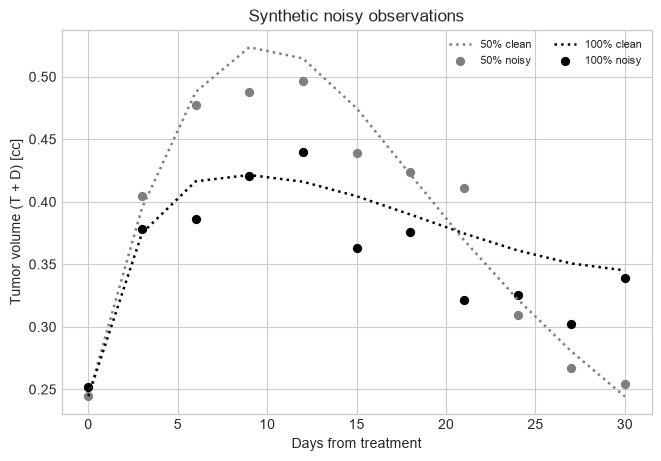

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
for series in dataset.series:
    color = 'tab:gray' if np.isclose(series.coverage, 0.5) else 'black'
    label = '50%' if np.isclose(series.coverage, 0.5) else '100%'
    ax.plot(series.relative_days, series.clean_volume, color=color, linestyle=':', linewidth=1.8, label=f'{label} clean')
    ax.scatter(series.relative_days, series.observed_volume, color=color, s=32, label=f'{label} noisy')
ax.set_title('Synthetic noisy observations')
ax.set_xlabel('Days from treatment')
ax.set_ylabel('Tumor volume (T + D) [cc]')
ax.legend(fontsize=8, ncol=2)
plt.show()


## 6. fitting 실행

이제 synthetic noisy data를 가지고 $\theta = (\psi, \omega, \kappa, T_0)$를 추정합니다.


In [7]:
fit_result = fit_synthetic_dataset(
    dataset,
    base_params=base_params,
    fit_specs=DEFAULT_FIT_SPECS,
    seed=11,
)

parameter_table(fit_result)


,parameter,true,fitted,rel_error_pct
0,psi,300.000,305.2886,1.7629
1,omega,0.135,0.1372,1.5928
2,k,1.100,1.1045,0.4105
3,initial_volume,0.030,0.0300,-0.0513


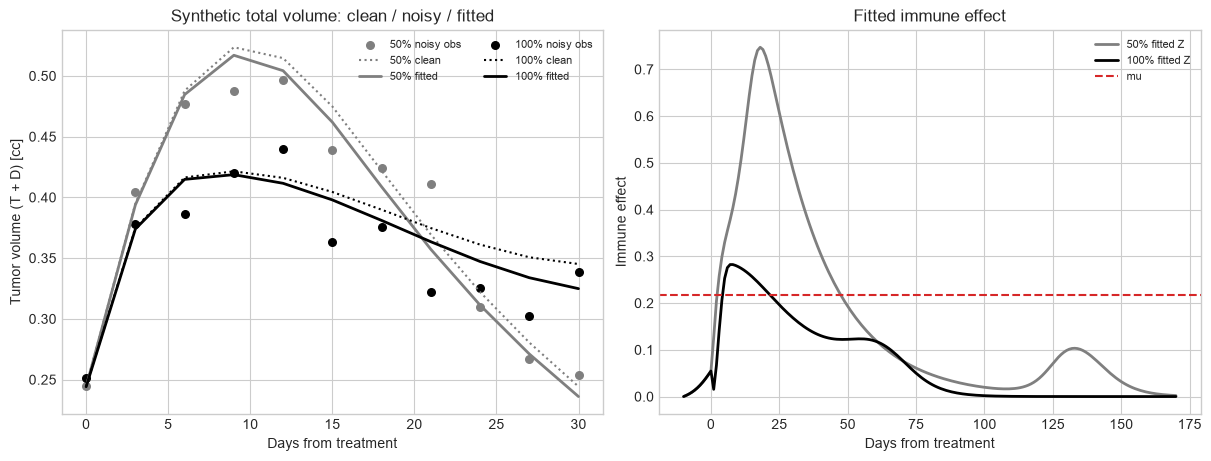

global_cost   = 0.088111
local_cost    = 0.088028
residual_norm = 0.296695


In [8]:
plot_figure4_style_fit(dataset, fit_result)
print(f'global_cost   = {fit_result.global_cost:.6f}')
print(f'local_cost    = {fit_result.local_cost:.6f}')
print(f'residual_norm = {fit_result.residual_norm:.6f}')


## 7. 결과 해석

이 단계에서 보면:

- `T_0`는 비교적 잘 복원됩니다.
- `psi`, `omega`, `kappa`도 synthetic noisy case에서는 꽤 잘 맞습니다.
- 하지만 이것이 곧바로 실데이터에서 identifiability가 충분하다는 뜻은 아닙니다.

그래서 다음으로 **noise level이 올라가면 얼마나 성능이 떨어지는지**를 확인합니다.


## 8. noise level experiment

아래 실험은 noise level을 바꾸면서 같은 fitting을 반복합니다.

- noise levels: `0.02`, `0.05`, `0.08`, `0.12`
- repeats per level: `3`

노트북 실행 시간을 줄이기 위해 이 섹션에서는 optimizer 설정을 약간 가볍게 사용합니다.


In [9]:
def run_noise_sweep(noise_levels=(0.02, 0.05, 0.08, 0.12), repeats=3):
    rows = []
    for noise_sigma in noise_levels:
        for repeat in range(repeats):
            dataset = generate_synthetic_dataset(
                true_params,
                coverages=(0.5, 1.0),
                noise_sigma=float(noise_sigma),
                seed=100 + 10 * repeat + int(100 * noise_sigma),
            )
            fit_result = fit_synthetic_dataset(
                dataset,
                base_params=base_params,
                fit_specs=DEFAULT_FIT_SPECS,
                seed=200 + repeat,
                de_maxiter=20,
                de_popsize=8,
                local_max_nfev=120,
            )
            rel_errors = []
            row = {
                'noise_sigma': float(noise_sigma),
                'repeat': repeat,
                'local_cost': fit_result.local_cost,
                'residual_norm': fit_result.residual_norm,
            }
            for spec in fit_result.parameter_specs:
                truth = fit_result.true_values[spec.name]
                fitted = fit_result.fitted_values[spec.name]
                abs_rel_error_pct = 100.0 * abs((fitted - truth) / truth)
                row[f'{spec.name}_abs_rel_error_pct'] = abs_rel_error_pct
                rel_errors.append(abs_rel_error_pct)
            row['mean_abs_rel_error_pct'] = float(np.mean(rel_errors))
            row['median_abs_rel_error_pct'] = float(np.median(rel_errors))
            rows.append(row)
    return pd.DataFrame(rows)

noise_results = run_noise_sweep()
noise_results.head()


,noise_sigma,repeat,local_cost,residual_norm,psi_abs_rel_error_pct,omega_abs_rel_error_pct,k_abs_rel_error_pct,initial_volume_abs_rel_error_pct,mean_abs_rel_error_pct,median_abs_rel_error_pct
0,0.02,0,0.0108,0.1041,0.0436,0.2605,0.1966,0.0753,0.1440,0.1359
1,0.02,1,0.0090,0.0949,0.0334,0.2529,0.3358,0.4798,0.2755,0.2944
2,0.02,2,0.0091,0.0956,0.0323,0.0393,0.0510,0.4422,0.1412,0.0452
3,0.05,0,0.0667,0.2583,1.5726,0.3095,1.1893,0.6791,0.9376,0.9342
4,0.05,1,0.0387,0.1968,0.1979,0.3129,0.1007,1.2090,0.4551,0.2554


In [10]:
noise_summary = (
    noise_results
    .groupby('noise_sigma', as_index=False)
    .agg(
        mean_fit_error_pct=('mean_abs_rel_error_pct', 'mean'),
        std_fit_error_pct=('mean_abs_rel_error_pct', 'std'),
        median_fit_error_pct=('median_abs_rel_error_pct', 'mean'),
        residual_norm_mean=('residual_norm', 'mean'),
        psi_error_pct=('psi_abs_rel_error_pct', 'mean'),
        omega_error_pct=('omega_abs_rel_error_pct', 'mean'),
        k_error_pct=('k_abs_rel_error_pct', 'mean'),
        initial_volume_error_pct=('initial_volume_abs_rel_error_pct', 'mean'),
    )
)
noise_summary


,noise_sigma,mean_fit_error_pct,std_fit_error_pct,median_fit_error_pct,residual_norm_mean,psi_error_pct,omega_error_pct,k_error_pct,initial_volume_error_pct
0,0.02,0.1869,0.0767,0.1585,0.0982,0.0364,0.1843,0.1945,0.3324
1,0.05,0.8478,0.3563,0.6444,0.2249,0.8730,0.2132,0.6429,1.6621
2,0.08,0.7950,0.1363,0.5067,0.4241,0.4423,0.5668,0.7100,1.4607
3,0.12,1.2674,0.4201,0.9829,0.5759,0.4903,0.6402,1.0377,2.9013


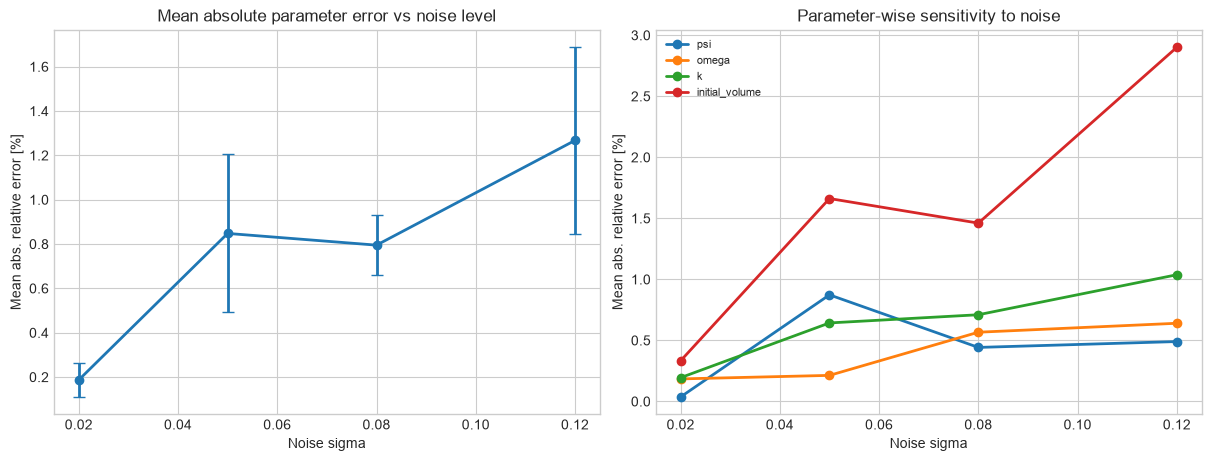

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].errorbar(
    noise_summary['noise_sigma'],
    noise_summary['mean_fit_error_pct'],
    yerr=noise_summary['std_fit_error_pct'].fillna(0.0),
    marker='o',
    linewidth=2,
    capsize=4,
)
axes[0].set_title('Mean absolute parameter error vs noise level')
axes[0].set_xlabel('Noise sigma')
axes[0].set_ylabel('Mean abs. relative error [%]')

for parameter in ['psi_error_pct', 'omega_error_pct', 'k_error_pct', 'initial_volume_error_pct']:
    axes[1].plot(
        noise_summary['noise_sigma'],
        noise_summary[parameter],
        marker='o',
        linewidth=2,
        label=parameter.replace('_error_pct', ''),
    )
axes[1].set_title('Parameter-wise sensitivity to noise')
axes[1].set_xlabel('Noise sigma')
axes[1].set_ylabel('Mean abs. relative error [%]')
axes[1].legend(fontsize=8)
plt.show()


## 9. noise experiment 해석

이 실험에서 보통 확인할 수 있는 패턴은 다음과 같습니다.

- noise level이 커질수록 fitting error가 커집니다.
- `T_0`는 상대적으로 잘 버팁니다.
- `psi`, `omega`, `kappa`는 noise가 커질수록 더 흔들립니다.
- 즉 Figure 4 스타일의 `T + D` 데이터만으로는 면역 관련 파라미터가 noise에 더 민감합니다.

이 결과는 실데이터 단계에서 왜 additional immune readout 또는 Bayesian uncertainty quantification이 필요한지를 보여줍니다.


## 10. 요약

이 노트북에서 한 일은 다음과 같습니다.

1. Figure 4 스타일 synthetic clean data 생성
2. multiplicative noise 추가
3. `psi`, `omega`, `kappa`, `T_0` fitting
4. fitting objective와 방법론을 수식으로 설명
5. noise level별 fitting 성능 비교

다음 단계로는:
- observability study (`T + D + Z`, `T + D + L` 등)
- dose × coverage grid
- Figure 5형 treatment timing study
- Bayesian posterior sampling

으로 확장할 수 있습니다.
